In [8]:
# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# JSON handling
import json

# SQL database
import sqlite3

# File and path handling
from pathlib import Path

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', 1000)

print("All libraries imported successfully!")

All libraries imported successfully!


In [9]:
from pathlib import Path

print("Files inside Dataset folder:")

for file in Path("../Dataset").iterdir():
    print(file.name)

Files inside Dataset folder:
city_zones.sql
riders.xlsx
trips.json


# 1.DATA UNDERSTANDING & LOADED

In [10]:
riders = pd.read_excel("../Dataset/riders.xlsx")

print("Riders data loaded successfully!")
riders.head()

Riders data loaded successfully!


,rider_id,name,age,gender,city,signup_date,total_rides,cancelled_rides,avg_rating
0,R0001,Aarav Das,23,Male,Pune,2020-06-29,56,0,3.76
1,R0002,Ishaan Nair,39,Female,Mumbai,2019-11-23,70,5,4.12
2,R0003,Kavya Reddy,34,Male,Pune,2023-05-04,45,9,3.76
3,R0004,Aarav Nair,19,Other,Kolkata,2019-07-28,464,5,3.19
4,R0005,Diya Reddy,27,Male,Ahmedabad,2021-05-31,294,30,3.53


### Riders data Loded

In [11]:
with open("../Dataset/trips.json", "r", encoding="utf-8") as file:
    trips_data = json.load(file)

trips = pd.DataFrame(trips_data)

print("Trips data loaded successfully!")
trips.head()

Trips data loaded successfully!


,trip_id,rider_id,zone,distance_km,duration_min,fare_amount,payment_mode,ride_date,surge_flag
0,T00001,R0037,Zone_10,11.83,74.59,104.88,Cash,2023-11-13,0
1,T00002,R0104,Zone_9,3.86,35.59,40.48,Cash,2023-07-28,1
2,T00003,R0045,Zone_8,4.70,31.03,46.39,Cash,2024-01-14,1
3,T00004,R0089,Zone_2,11.06,59.48,257.64,Cash,2023-12-13,0
4,T00005,R0003,Zone_5,7.28,67.59,72.74,UPI,2023-03-15,1


### Trips Data Loaded

In [12]:
with open("../Dataset/city_zones.sql", "r", encoding="utf-8") as file:
    sql_script = file.read()

print("SQL file loaded successfully!")

SQL file loaded successfully!


In [13]:
# Load city zones data from SQL file

import sqlite3

# Create an in-memory SQLite database
connection = sqlite3.connect(":memory:")

# Read SQL file
with open("../Dataset/city_zones.sql", "r", encoding="utf-8") as file:
    sql_script = file.read()

# Execute SQL script
connection.executescript(sql_script)

# Convert city_zones table into a DataFrame
city_zones = pd.read_sql_query(
    "SELECT * FROM city_zones",
    connection
)

print("City Zones data loaded successfully!")
display(city_zones.head())

City Zones data loaded successfully!


,zone_name,population_density,traffic_index,avg_speed_kmph,zone_type
0,Zone_1,4921,2.43,30.9,Residential
1,Zone_2,6371,0.91,58.4,Residential
2,Zone_3,12971,2.11,38.0,Business
3,Zone_4,4038,2.46,48.2,Business
4,Zone_5,2590,1.31,43.9,Business


### SQL file Loaded

In [14]:
print("========== RIDERS DATA ==========")
print("Shape:", riders.shape)
print("Columns:", riders.columns.tolist())

print("\n========== TRIPS DATA ==========")
print("Shape:", trips.shape)
print("Columns:", trips.columns.tolist())

print("\n========== CITY ZONES DATA ==========")
print("Shape:", city_zones.shape)
print("Columns:", city_zones.columns.tolist())

========== RIDERS DATA ==========
Shape: (300, 9)
Columns: ['rider_id', 'name', 'age', 'gender', 'city', 'signup_date', 'total_rides', 'cancelled_rides', 'avg_rating']

========== TRIPS DATA ==========
Shape: (2000, 9)
Columns: ['trip_id', 'rider_id', 'zone', 'distance_km', 'duration_min', 'fare_amount', 'payment_mode', 'ride_date', 'surge_flag']

========== CITY ZONES DATA ==========
Shape: (10, 5)
Columns: ['zone_name', 'population_density', 'traffic_index', 'avg_speed_kmph', 'zone_type']


## 1.1 Data Structure Overview

The basic structure of all three datasets is examined using their shapes and column names.

This helps us understand the number of records and attributes available in each dataset before performing data cleaning and transformation.

In [15]:
# Display the first 5 rows of all datasets

print("========== RIDERS SAMPLE ==========")
display(riders.head())

print("========== TRIPS SAMPLE ==========")
display(trips.head())

print("========== CITY ZONES SAMPLE ==========")
display(city_zones.head())

========== RIDERS SAMPLE ==========


,rider_id,name,age,gender,city,signup_date,total_rides,cancelled_rides,avg_rating
0,R0001,Aarav Das,23,Male,Pune,2020-06-29,56,0,3.76
1,R0002,Ishaan Nair,39,Female,Mumbai,2019-11-23,70,5,4.12
2,R0003,Kavya Reddy,34,Male,Pune,2023-05-04,45,9,3.76
3,R0004,Aarav Nair,19,Other,Kolkata,2019-07-28,464,5,3.19
4,R0005,Diya Reddy,27,Male,Ahmedabad,2021-05-31,294,30,3.53


========== TRIPS SAMPLE ==========


,trip_id,rider_id,zone,distance_km,duration_min,fare_amount,payment_mode,ride_date,surge_flag
0,T00001,R0037,Zone_10,11.83,74.59,104.88,Cash,2023-11-13,0
1,T00002,R0104,Zone_9,3.86,35.59,40.48,Cash,2023-07-28,1
2,T00003,R0045,Zone_8,4.70,31.03,46.39,Cash,2024-01-14,1
3,T00004,R0089,Zone_2,11.06,59.48,257.64,Cash,2023-12-13,0
4,T00005,R0003,Zone_5,7.28,67.59,72.74,UPI,2023-03-15,1


========== CITY ZONES SAMPLE ==========


,zone_name,population_density,traffic_index,avg_speed_kmph,zone_type
0,Zone_1,4921,2.43,30.9,Residential
1,Zone_2,6371,0.91,58.4,Residential
2,Zone_3,12971,2.11,38.0,Business
3,Zone_4,4038,2.46,48.2,Business
4,Zone_5,2590,1.31,43.9,Business


## 1.2 Sample Data Inspection

The first five records of each dataset are displayed to understand the structure and values of the available data.

This initial inspection helps us understand the type of information available before performing data cleaning and transformation.

In [16]:
# Check data types and non-null values

print("========== RIDERS INFO ==========")
riders.info()

print("\n========== TRIPS INFO ==========")
trips.info()

print("\n========== CITY ZONES INFO ==========")
city_zones.info()

========== RIDERS INFO ==========
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   rider_id         300 non-null    object        
 1   name             300 non-null    object        
 2   age              300 non-null    int64         
 3   gender           300 non-null    object        
 4   city             300 non-null    object        
 5   signup_date      300 non-null    datetime64[ns]
 6   total_rides      300 non-null    int64         
 7   cancelled_rides  300 non-null    int64         
 8   avg_rating       300 non-null    float64       
dtypes: datetime64[ns](1), float64(1), int64(3), object(4)
memory usage: 21.2+ KB

========== TRIPS INFO ==========
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------   

## 1.3 Data Types and Non-Null Values

The `info()` method is used to examine the column names, data types, number of non-null values, and overall structure of each dataset.

This helps identify columns that may require data type conversion or missing-value treatment.

In [17]:
# Check missing values

print("========== RIDERS MISSING VALUES ==========")
display(riders.isnull().sum().to_frame("Missing Values"))

print("\n========== TRIPS MISSING VALUES ==========")
display(trips.isnull().sum().to_frame("Missing Values"))

print("\n========== CITY ZONES MISSING VALUES ==========")
display(city_zones.isnull().sum().to_frame("Missing Values"))

========== RIDERS MISSING VALUES ==========


,Missing Values
rider_id,0
name,0
age,0
gender,0
city,0
signup_date,0
total_rides,0
cancelled_rides,0
avg_rating,0



========== TRIPS MISSING VALUES ==========


,Missing Values
trip_id,0
rider_id,0
zone,0
distance_km,0
duration_min,0
fare_amount,0
payment_mode,0
ride_date,0
surge_flag,0



========== CITY ZONES MISSING VALUES ==========


,Missing Values
zone_name,0
population_density,0
traffic_index,0
avg_speed_kmph,0
zone_type,0


## 1.4 Missing Value Analysis

Missing values are checked in all three datasets using `isnull().sum()`.

The result shows the number of missing values present in each column and helps determine whether any cleaning is required.

In [18]:
# Check duplicate records

print("========== DUPLICATE RECORDS ==========")

print("Riders duplicates:", riders.duplicated().sum())
print("Trips duplicates:", trips.duplicated().sum())
print("City Zones duplicates:", city_zones.duplicated().sum())

========== DUPLICATE RECORDS ==========
Riders duplicates: 0
Trips duplicates: 0
City Zones duplicates: 0


## 1.5 Duplicate Record Analysis

Duplicate records are identified in each dataset using the `duplicated()` method.

This check helps ensure that repeated records do not affect the accuracy of the analysis.

In [19]:
# Generate descriptive statistics

print("========== RIDERS STATISTICS ==========")
display(riders.describe(include="all").T)

print("========== TRIPS STATISTICS ==========")
display(trips.describe(include="all").T)

print("========== CITY ZONES STATISTICS ==========")
display(city_zones.describe(include="all").T)

========== RIDERS STATISTICS ==========


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
rider_id,300,300,R0001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
name,300,96,Aarav Nair,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,300.0,NaN,NaN,NaN,31.466667,18.0,26.0,31.0,37.0,55.0,7.863098
gender,300,3,Male,108,NaN,NaN,NaN,NaN,NaN,NaN,NaN
city,300,10,Mumbai,35,NaN,NaN,NaN,NaN,NaN,NaN,NaN
signup_date,300,NaN,NaN,NaN,2021-05-23 06:57:36,2019-01-01 00:00:00,2020-03-04 00:00:00,2021-05-11 00:00:00,2022-09-14 18:00:00,2023-12-06 00:00:00,NaN
total_rides,300.0,NaN,NaN,NaN,244.69,4.0,112.75,241.0,366.75,499.0,146.406843
cancelled_rides,300.0,NaN,NaN,NaN,22.983333,0.0,7.0,16.0,32.0,94.0,21.455633
avg_rating,300.0,NaN,NaN,NaN,3.991,3.0,3.5475,3.925,4.48,5.0,0.559643


========== TRIPS STATISTICS ==========


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
trip_id,2000,2000,T00001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
rider_id,2000,299,R0252,16,NaN,NaN,NaN,NaN,NaN,NaN,NaN
zone,2000,10,Zone_1,233,NaN,NaN,NaN,NaN,NaN,NaN,NaN
distance_km,2000.0,NaN,NaN,NaN,8.24742,4.450904,0.02,4.8875,8.115,11.3625,25.86
duration_min,2000.0,NaN,NaN,NaN,61.88341,35.980603,0.19,35.415,58.95,85.375,201.07
fare_amount,2000.0,NaN,NaN,NaN,134.600375,85.521989,0.25,70.44,121.85,182.8675,472.29
payment_mode,2000,4,Cash,513,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ride_date,2000,589,2023-09-08,11,NaN,NaN,NaN,NaN,NaN,NaN,NaN
surge_flag,2000.0,NaN,NaN,NaN,0.5105,0.500015,0.0,0.0,1.0,1.0,1.0


========== CITY ZONES STATISTICS ==========


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
zone_name,10,10,Zone_1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
population_density,10.0,NaN,NaN,NaN,7458.1,4527.581706,2440.0,4157.5,5646.0,11061.75,14627.0
traffic_index,10.0,NaN,NaN,NaN,1.57,0.703199,0.54,1.01,1.685,2.065,2.46
avg_speed_kmph,10.0,NaN,NaN,NaN,42.47,9.666557,30.9,35.95,40.95,47.45,58.4
zone_type,10,4,Business,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 1.6 Descriptive Statistics

Descriptive statistics are generated for the datasets to understand their numerical and categorical variables.

This provides an initial overview of the data distribution and helps identify unusual or unexpected values that may require further investigation.

In [20]:
# Check unique values in important categorical columns

print("========== RIDERS ==========")

for column in riders.select_dtypes(include="object").columns:
    print(f"\n{column}:")
    print(riders[column].unique()[:20])

print("\n========== TRIPS ==========")

for column in trips.select_dtypes(include="object").columns:
    print(f"\n{column}:")
    print(trips[column].unique()[:20])

print("\n========== CITY ZONES ==========")

for column in city_zones.select_dtypes(include="object").columns:
    print(f"\n{column}:")
    print(city_zones[column].unique()[:20])

========== RIDERS ==========

rider_id:
['R0001' 'R0002' 'R0003' 'R0004' 'R0005' 'R0006' 'R0007' 'R0008' 'R0009'
 'R0010' 'R0011' 'R0012' 'R0013' 'R0014' 'R0015' 'R0016' 'R0017' 'R0018'
 'R0019' 'R0020']

name:
['Aarav Das' 'Ishaan Nair' 'Kavya Reddy' 'Aarav Nair' 'Diya Reddy'
 'Ishaan Ghosh' 'Diya Patel' 'Vivaan Gupta' 'Vivaan Nair' 'Ishaan Gupta'
 'Saanvi Patel' 'Aarav Iyer' 'Meera Das' 'Aarav Reddy' 'Kavya Patel'
 'Diya Das' 'Diya Ghosh' 'Meera Iyer' 'Meera Kumar' 'Aarav Kumar']

gender:
['Male' 'Female' 'Other']

city:
['Pune' 'Mumbai' 'Kolkata' 'Ahmedabad' 'Jaipur' 'Surat' 'Chennai'
 'Hyderabad' 'Delhi' 'Bengaluru']

========== TRIPS ==========

trip_id:
['T00001' 'T00002' 'T00003' 'T00004' 'T00005' 'T00006' 'T00007' 'T00008'
 'T00009' 'T00010' 'T00011' 'T00012' 'T00013' 'T00014' 'T00015' 'T00016'
 'T00017' 'T00018' 'T00019' 'T00020']

rider_id:
['R0037' 'R0104' 'R0045' 'R0089' 'R0003' 'R0255' 'R0224' 'R0039' 'R0223'
 'R0236' 'R0191' 'R0199' 'R0248' 'R0300' 'R0270' 'R0216' 'R0168'

## 1.7 Categorical Value Inspection

Unique values of categorical columns are inspected to identify different categories present in the datasets.

This check is useful for detecting inconsistent labels, unexpected categories, or formatting issues before data cleaning.

# 2.DATA CLEANING

In [21]:
from sklearn.impute import SimpleImputer

num_cols = riders.select_dtypes(include=np.number).columns

imputer = SimpleImputer(strategy="mean")
riders[num_cols] = imputer.fit_transform(riders[num_cols])

print("Numeric missing values handled.")

Numeric missing values handled.


## 2.1 Numeric Missing Values

Numeric missing values are filled using the mean strategy of SimpleImputer.

In [22]:
cat_cols = riders.select_dtypes(include="object").columns

imputer = SimpleImputer(strategy="most_frequent")
riders[cat_cols] = imputer.fit_transform(riders[cat_cols])

print("Categorical missing values handled.")

Categorical missing values handled.


## 2.2 Categorical Missing Values

Categorical missing values are filled using the most frequent value.

In [23]:
from sklearn.impute import KNNImputer

cols = ["duration_min", "distance_km", "fare_amount"]

imputer = KNNImputer(n_neighbors=5)
trips[cols] = imputer.fit_transform(trips[cols])

print("KNN imputation completed.")

KNN imputation completed.


## 2.3 KNN Imputation

KNN Imputer is used to handle missing values in trip duration, distance, and fare amount.

In [24]:
trips["ride_date"] = pd.to_datetime(trips["ride_date"], errors="coerce")

print("Date format converted successfully.")

Date format converted successfully.


## 2.4 Date Format Standardization

The ride date is converted into a consistent datetime format.

In [25]:
# Remove negative fare
trips = trips[trips["fare_amount"] >= 0]

# Remove zero-distance rides with fare
trips = trips[
    ~((trips["distance_km"] == 0) & (trips["fare_amount"] > 0))
]

print("Unrealistic records removed.")

Unrealistic records removed.


## 2.5 Remove Unrealistic Records

Negative fares and zero-distance rides with a billed fare are removed from the dataset.

# 3.OUTLIERS HANDLING

In [26]:
from scipy.stats import zscore

# Z-score for fare and distance
trips["fare_z"] = zscore(trips["fare_amount"])
trips["distance_z"] = zscore(trips["distance_km"])

print("Fare anomalies:", (abs(trips["fare_z"]) > 3).sum())
print("Distance anomalies:", (abs(trips["distance_z"]) > 3).sum())

Fare anomalies: 16
Distance anomalies: 3


## 3.1 Z-Score Outlier Detection

Z-score is used to detect unusual values in fare and distance.

Values with a Z-score greater than 3 or less than -3 are considered anomalies.

In [27]:
Q1 = trips["duration_min"].quantile(0.25)
Q3 = trips["duration_min"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

duration_outliers = trips[
    (trips["duration_min"] < lower) |
    (trips["duration_min"] > upper)
]

print("Duration outliers:", len(duration_outliers))

Duration outliers: 18


## 3.2 IQR Outlier Detection

The IQR method is used to identify unusual ride durations.

Values below the lower limit or above the upper limit are considered outliers.

In [28]:
from scipy.stats.mstats import winsorize

before = trips["fare_amount"].copy()

trips["fare_amount"] = winsorize(
    trips["fare_amount"], limits=[0.01, 0.01]
)

print("Winsorization applied to fare amount.")

Winsorization applied to fare amount.


## 3.3 Winsorization

Winsorization is applied to fare amounts to reduce the effect of extreme values.

The extreme 1% values from both ends are limited.

In [29]:
print("========== BEFORE vs AFTER ==========")

print("Before Mean Fare:", before.mean())
print("After Mean Fare:", trips["fare_amount"].mean())

print("\nBefore Maximum Fare:", before.max())
print("After Maximum Fare:", trips["fare_amount"].max())

========== BEFORE vs AFTER ==========
Before Mean Fare: 134.600375
After Mean Fare: 134.22503

Before Maximum Fare: 472.29
After Maximum Fare: 379.63


## 3.4 Before vs After Comparison

The fare values are compared before and after Winsorization.

This shows how extreme fare values were reduced while keeping the main data distribution.

# 4.DATA TRANSFORMATION

In [30]:
# 4.1 Datetime Transformation

trips["ride_date"] = pd.to_datetime(trips["ride_date"])

trips["hour"] = trips["ride_date"].dt.hour
trips["day_of_week"] = trips["ride_date"].dt.day_name()
trips["month"] = trips["ride_date"].dt.month_name()

print("Datetime columns created.")

Datetime columns created.


## 4.1 Datetime Transformation

The ride date is transformed into hour, day of week, and month columns.

In [31]:
# 4.2 Label Encoding

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

if "gender" in riders.columns:
    riders["gender_encoded"] = le.fit_transform(riders["gender"])

print("Gender label encoding completed.")

Gender label encoding completed.


## 4.2 Label Encoding

The gender column is converted into numerical values using Label Encoding.

In [32]:
# 4.3 One-Hot Encoding

trips = pd.get_dummies(
    trips,
    columns=["payment_mode", "zone"],
    dtype=int
)

print("One-hot encoding completed.")

One-hot encoding completed.


## 4.3 One-Hot Encoding

Payment mode and zone categories are converted into separate numerical columns using One-Hot Encoding.

In [33]:
# 4.4 Customer Ride Frequency Binning

ride_count = trips.groupby("rider_id").size()

riders["ride_frequency"] = riders["rider_id"].map(ride_count).fillna(0)

riders["ride_frequency_level"] = pd.cut(
    riders["ride_frequency"],
    bins=[-1, 5, 10, float("inf")],
    labels=["Low", "Medium", "High"]
)

print("Ride frequency binning completed.")

Ride frequency binning completed.


## 4.4 Binning

Customer ride frequency is divided into three categories:

- Low
- Medium
- High

In [34]:
# 4.5 Skewed Data Transformation

trips["log_fare"] = np.log1p(trips["fare_amount"])
trips["log_distance"] = np.log1p(trips["distance_km"])
trips["sqrt_duration"] = np.sqrt(trips["duration_min"])

print("Skewed columns transformed.")

Skewed columns transformed.


## 4.5 Skewed Data Transformation

Log transformation is applied to fare and distance, while square-root transformation is applied to duration.

These transformations help reduce the effect of skewed values.

# 5.FEATURE SCALLING

In [35]:
# 5.1 StandardScaler

from sklearn.preprocessing import StandardScaler

scale_cols = ["distance_km", "duration_min", "fare_amount"]

scaler = StandardScaler()

trips_standard = trips.copy()
trips_standard[scale_cols] = scaler.fit_transform(trips[scale_cols])

print("Standard Scaling completed.")

Standard Scaling completed.


## 5.1 StandardScaler

StandardScaler is used to standardize distance, duration, and fare values.

In [36]:
# 5.2 MinMaxScaler

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

trips_minmax = trips.copy()
trips_minmax[scale_cols] = scaler.fit_transform(trips[scale_cols])

print("Min-Max Scaling completed.")

Min-Max Scaling completed.


## 5.2 MinMaxScaler

MinMaxScaler converts the selected numerical features into a common range between 0 and 1.

In [37]:
# 5.3 Before vs After Statistics

print("========== BEFORE SCALING ==========")
display(trips[scale_cols].describe().T)

print("========== AFTER STANDARD SCALING ==========")
display(trips_standard[scale_cols].describe().T)

print("========== AFTER MIN-MAX SCALING ==========")
display(trips_minmax[scale_cols].describe().T)

========== BEFORE SCALING ==========


,count,mean,std,min,25%,50%,75%,max
distance_km,2000.0,8.24742,4.450904,0.02,4.8875,8.115,11.3625,25.86
duration_min,2000.0,61.88341,35.980603,0.19,35.4150,58.950,85.3750,201.07
fare_amount,2000.0,134.22503,84.221107,3.27,70.4400,121.850,182.8675,379.63


========== AFTER STANDARD SCALING ==========


,count,mean,std,min,25%,50%,75%,max
distance_km,2000.0,5.329071e-18,1.00025,-1.848945,-0.755074,-0.029759,0.700051,3.958069
duration_min,2000.0,-1.172396e-16,1.00025,-1.715058,-0.735814,-0.081548,0.653059,3.869346
fare_amount,2000.0,-3.375078e-17,1.00025,-1.555284,-0.757541,-0.146972,0.577701,2.914547


========== AFTER MIN-MAX SCALING ==========


,count,mean,std,min,25%,50%,75%,max
distance_km,2000.0,0.318399,0.172249,0.0,0.188371,0.313274,0.438951,1.0
duration_min,2000.0,0.307116,0.179115,0.0,0.175353,0.292513,0.424059,1.0
fare_amount,2000.0,0.347952,0.223778,0.0,0.178473,0.315071,0.477196,1.0


## 5.3 Before vs After Statistics

The statistics of numerical features are compared before and after scaling.

This helps understand the effect of StandardScaler and MinMaxScaler on the data.

# 6.FEATURE CONSTRUCTION

In [38]:
# 6.1 Average Ride Distance and Fare

avg_features = trips.groupby("rider_id").agg(
    avg_ride_distance=("distance_km", "mean"),
    avg_ride_fare=("fare_amount", "mean")
)

riders = riders.join(avg_features, on="rider_id")

print("Average ride features created.")

Average ride features created.


## 6.1 Average Ride Distance and Fare

Average ride distance and average ride fare are calculated for each rider.

In [39]:
# 6.2 Peak Hour

trips["is_peak_hour"] = trips["hour"].isin(
    [7, 8, 9, 18, 19, 20, 21]
).astype(int)

print("Peak hour feature created.")

Peak hour feature created.


## 6.2 Peak Hour Feature

A new feature `is_peak_hour` is created.

It is 1 for peak hours (7–9 AM and 6–9 PM), otherwise 0.

In [40]:
# 6.3 Days Since Signup

if "signup_date" in riders.columns:
    riders["signup_date"] = pd.to_datetime(riders["signup_date"])
    riders["days_since_signup"] = (
        pd.Timestamp.today() - riders["signup_date"]
    ).dt.days

print("Days since signup feature created.")

Days since signup feature created.


## 6.3 Days Since Signup

The number of days since each rider's signup date is calculated.

In [41]:
# 6.4 Ride Cancellation Rate

if "cancelled" in trips.columns:
    cancel_rate = trips.groupby("rider_id")["cancelled"].mean()
    riders["ride_cancellation_rate"] = riders["rider_id"].map(cancel_rate)
    print("Cancellation rate created.")
else:
    print("Cancellation column is not available in the Trips dataset.")

Cancellation column is not available in the Trips dataset.


## 6.4 Ride Cancellation Rate

The ride cancellation rate is calculated as cancelled rides divided by total rides.

If cancellation information is not available in the dataset, the feature cannot be calculated.

In [42]:
# 6.5 Surge Flag

trips["surge_flag"] = (
    trips["fare_amount"] / trips["distance_km"] > 20
).astype(int)

print("Surge flag feature created.")

Surge flag feature created.


## 6.5 Surge Flag

A surge flag is created based on fare per distance.

A value of 1 indicates a fare above the selected threshold; otherwise it is 0.

In [43]:
# 6.6 Check New Features

print("Riders new features:")
display(riders.head())

print("\nTrips new features:")
display(trips[["rider_id", "avg_ride_distance" if "avg_ride_distance" in trips.columns else "distance_km",
              "is_peak_hour", "surge_flag"]].head())

Riders new features:


,rider_id,name,age,gender,city,signup_date,total_rides,cancelled_rides,avg_rating,gender_encoded,ride_frequency,ride_frequency_level,avg_ride_distance,avg_ride_fare,days_since_signup
0,R0001,Aarav Das,23.0,Male,Pune,2020-06-29,56.0,0.0,3.76,1,2.0,Low,10.420000,158.785000,2264
1,R0002,Ishaan Nair,39.0,Female,Mumbai,2019-11-23,70.0,5.0,4.12,0,7.0,Medium,10.812857,167.944286,2483
2,R0003,Kavya Reddy,34.0,Male,Pune,2023-05-04,45.0,9.0,3.76,1,10.0,Medium,6.768000,97.171000,1225
3,R0004,Aarav Nair,19.0,Other,Kolkata,2019-07-28,464.0,5.0,3.19,2,6.0,Medium,6.201667,113.838333,2601
4,R0005,Diya Reddy,27.0,Male,Ahmedabad,2021-05-31,294.0,30.0,3.53,1,7.0,Medium,7.322857,132.350000,1928



Trips new features:


,rider_id,distance_km,is_peak_hour,surge_flag
0,R0037,11.83,0,0
1,R0104,3.86,0,0
2,R0045,4.70,0,0
3,R0089,11.06,0,1
4,R0003,7.28,0,0


# 7.FINAL DATASET

In [44]:
# 7.1 Merge Datasets

final_data = trips.merge(
    riders,
    on="rider_id",
    how="left"
)

print("Final dataset shape:", final_data.shape)
display(final_data.head())

Final dataset shape: (2000, 44)


,trip_id,rider_id,distance_km,duration_min,fare_amount,ride_date,surge_flag,fare_z,distance_z,hour,day_of_week,month,payment_mode_Cash,payment_mode_Credit Card,payment_mode_UPI,payment_mode_Wallet,zone_Zone_1,zone_Zone_10,zone_Zone_2,zone_Zone_3,zone_Zone_4,zone_Zone_5,zone_Zone_6,zone_Zone_7,zone_Zone_8,zone_Zone_9,log_fare,log_distance,sqrt_duration,is_peak_hour,name,age,gender,city,signup_date,total_rides,cancelled_rides,avg_rating,gender_encoded,ride_frequency,ride_frequency_level,avg_ride_distance,avg_ride_fare,days_since_signup
0,T00001,R0037,11.83,74.59,104.88,2023-11-13,0,-0.347604,0.805112,0,Monday,November,1,0,0,0,0,1,0,0,0,0,0,0,0,0,4.662306,2.551786,8.636550,0,Aadhya Iyer,32.0,Other,Ahmedabad,2020-11-21,489.0,6.0,3.36,2,8.0,Medium,9.761250,164.332500,2119
1,T00002,R0104,3.86,35.59,40.48,2023-07-28,0,-1.100815,-0.985983,0,Friday,July,1,0,0,0,0,0,0,0,0,0,0,0,0,1,3.725211,1.581038,5.965735,0,Diya Gupta,52.0,Male,Kolkata,2021-05-27,328.0,1.0,3.70,1,9.0,Medium,5.187778,85.043333,1932
2,T00003,R0045,4.70,31.03,46.39,2024-01-14,0,-1.031693,-0.797210,0,Sunday,January,1,0,0,0,0,0,0,0,0,0,0,0,1,0,3.858411,1.740466,5.570458,0,Saanvi Iyer,34.0,Other,Ahmedabad,2023-07-12,100.0,16.0,4.88,2,9.0,Medium,9.725556,169.983333,1156
3,T00004,R0089,11.06,59.48,257.64,2023-12-13,1,1.439050,0.632070,0,Wednesday,December,1,0,0,0,0,0,1,0,0,0,0,0,0,0,5.555437,2.489894,7.712328,0,Saanvi Reddy,48.0,Other,Surat,2022-09-21,308.0,6.0,3.91,2,9.0,Medium,9.981111,157.283333,1450
4,T00005,R0003,7.28,67.59,72.74,2023-03-15,0,-0.723508,-0.217408,0,Wednesday,March,0,0,1,0,0,0,0,0,0,1,0,0,0,0,4.300545,2.113843,8.221314,0,Kavya Reddy,34.0,Male,Pune,2023-05-04,45.0,9.0,3.76,1,10.0,Medium,6.768000,97.171000,1225


## 7.1 Merge Cleaned and Enriched Datasets

The cleaned Trips and Riders datasets are merged using `rider_id`.

This creates a single dataset containing the available ride and rider information.

In [45]:
# 7.2 Add City Zone Information

zone_cols = [c for c in final_data.columns if c.startswith("zone_Zone_")]

if zone_cols:
    final_data["zone_name"] = final_data[zone_cols].idxmax(axis=1)
    final_data["zone_name"] = final_data["zone_name"].str.replace(
        "zone_", "", regex=False
    )

    final_data = final_data.merge(
        city_zones,
        on="zone_name",
        how="left"
    )

print("City zone information added.")

City zone information added.


## 7.2 Add City Zone Information

City zone information is added to the final dataset using the zone name.

This enriches the dataset with additional zone-level information.

In [46]:
# 7.3 Final Summary

summary = pd.DataFrame({
    "Metric": [
        "Final Rows",
        "Final Columns",
        "Missing Values",
        "Duplicate Rows",
        "Engineered Features"
    ],
    "Value": [
        len(final_data),
        final_data.shape[1],
        final_data.isnull().sum().sum(),
        final_data.duplicated().sum(),
        "avg_ride_distance, avg_ride_fare, is_peak_hour, surge_flag"
    ]
})

display(summary)

,Metric,Value
0,Final Rows,2000
1,Final Columns,49
2,Missing Values,0
3,Duplicate Rows,0
4,Engineered Features,"avg_ride_distance, avg_ride_fare, is_peak_hour..."


## 7.3 Final Dataset Summary

A summary table is created to show the final number of rows, columns, missing values, duplicate records, and engineered features.

In [47]:
# 7.4 Export Final Dataset

final_data.to_csv(
    "final_prepared_rides_dataset.csv",
    index=False
)

print("Final dataset exported successfully!")

Final dataset exported successfully!


## 7.4 Export Final Dataset

The final cleaned and enriched dataset is exported as:

`final_prepared_rides_dataset.csv`

The file can now be used for further analysis or machine learning.

# 8.OPTIONAL

In [ ]:
import sys
!{sys.executable} -m pip install "setuptools<81"

In [49]:
from ydata_profiling import ProfileReport

profile = ProfileReport(final_data, title="Rides Dataset EDA Report")
profile.to_file("rides_eda_report.html")

print("EDA report created successfully!")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 49/49 [00:01<00:00, 35.37it/s]
c:\Users\ADMIN\AppData\Local\Programs\Python\Python312\Lib\site-packages\ydata_profiling\model\pandas\discretize_pandas.py:52: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[4 4 4 ... 4 4 4]' has dtype incompatible with int32, please explicitly cast to a compatible dtype first.
  discretized_df.loc[:, column] = self._discretize_column(


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

EDA report created successfully!


In [50]:
# 8.2 Ride Demand by Hour

trips["hour"].value_counts().sort_index().plot(kind="bar")

plt.title("Ride Demand by Hour")
plt.xlabel("Hour")
plt.ylabel("Number of Rides")
plt.show()

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_9332\2416455591.py:8: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


## 8.2 Ride Demand by Hour

A bar chart is created to show the number of rides during different hours of the day.

In [53]:
%matplotlib inline

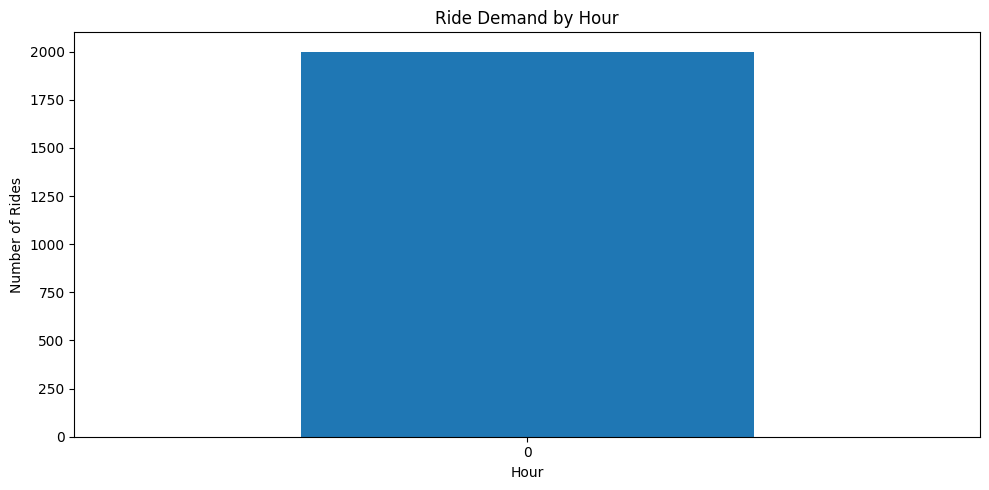

8.2 graph saved successfully!


In [60]:
from pathlib import Path

# Create images folder
Path("images").mkdir(exist_ok=True)

plt.figure(figsize=(10, 5))

trips["hour"].value_counts().sort_index().plot(kind="bar")

plt.title("Ride Demand by Hour")
plt.xlabel("Hour")
plt.ylabel("Number of Rides")
plt.xticks(rotation=0)
plt.tight_layout()

# Save graph as PNG
plt.savefig("images/ride_demand_by_hour.png", dpi=300, bbox_inches="tight")

plt.show()

print("8.2 graph saved successfully!")

## 8.2 Ride Demand by Hour

A bar chart is created to show the number of rides during different hours of the day.

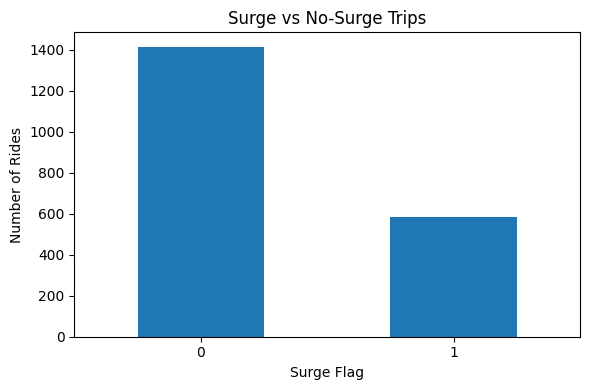

8.3 graph saved successfully!


In [61]:
plt.figure(figsize=(6, 4))

trips["surge_flag"].value_counts().sort_index().plot(kind="bar")

plt.title("Surge vs No-Surge Trips")
plt.xlabel("Surge Flag")
plt.ylabel("Number of Rides")
plt.xticks(rotation=0)
plt.tight_layout()

# Save graph as PNG
plt.savefig("images/surge_vs_no_surge.png", dpi=300, bbox_inches="tight")

plt.show()

print("8.3 graph saved successfully!")

## 8.3 Surge vs No-Surge Trip Patterns

A bar chart is used to compare trips with surge pricing and trips without surge pricing.